# Aerial Image Segmentation: Solving the Tiny Object Problem

## Problem Overview
Aerial imagery presents unique challenges for object detection and segmentation:
1. **The 'Tiny Object' Problem**: Objects like cars or people occupy very few pixels relative to the background.
2. **Computational Constraints**: High-resolution images (4K/8K) exceed GPU memory if processed directly.
3. **Orientation & Clutter**: Objects appear at arbitrary rotations and are camouflaged by complex textures.

## Solution Strategy
- **Patch-based Training (Tiling)**: We split massive images into smaller tiles (patches) to maintain resolution while fitting into GPU memory.
- **ResNet-UNet Architecture**: Using a pretrained ResNet18 encoder provides robust feature extraction for diverse textures.
- **Dice + CrossEntropy Hybrid Loss**: Specifically designed to handle class imbalance, ensuring tiny objects are correctly segmented.
- **Normalization**: Essential for pretrained models (using ImageNet stats).

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision import models

## 1. Setup Data Paths

In [2]:
DATA_DIR = r"D:\AeroX\Arial Images\dataset\semantic_drone_dataset"
IMG_DIR = os.path.join(DATA_DIR, 'original_images')
MASK_DIR = os.path.join(DATA_DIR, 'label_images_semantic')

images = sorted([os.path.join(IMG_DIR, f) for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
masks = sorted([os.path.join(MASK_DIR, f) for f in os.listdir(MASK_DIR) if f.endswith('.png')])

print(f"Total images: {len(images)}")
print(f"Total masks: {len(masks)}")


Total images: 400
Total masks: 400


## 2. Dataset and Tiling Strategy
Instead of resizing (which makes objects vanish), we use random patches.

In [4]:
class AerialDataset(Dataset):
    def __init__(self, image_paths, mask_paths, patch_size=512, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.patch_size = patch_size
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        h, w, _ = image.shape
        x = np.random.randint(0, w - self.patch_size)
        y = np.random.randint(0, h - self.patch_size)
        
        img_patch = image[y:y+self.patch_size, x:x+self.patch_size]
        mask_patch = mask[y:y+self.patch_size, x:x+self.patch_size]
        
        if self.transform:
            img_patch = self.transform(img_patch)
            
        mask_patch = torch.from_numpy(mask_patch).long()
        return img_patch, mask_patch

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 3. Pretrained ResNet-UNet Model

In [5]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
    )

class ResNetUNet(nn.Module):
    def __init__(self, n_class):
        super().__init__()
        self.base_model = models.resnet18(pretrained=True)
        self.base_layers = list(self.base_model.children())
        self.layer0 = nn.Sequential(*self.base_layers[:3])
        self.layer0_1 = nn.Sequential(*self.base_layers[3:5])
        self.layer1, self.layer2, self.layer3 = self.base_layers[5], self.base_layers[6], self.base_layers[7]
        
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up3 = double_conv(512 + 256, 256)
        self.conv_up2 = double_conv(256 + 128, 128)
        self.conv_up1 = double_conv(128 + 64, 64)
        self.conv_up0 = double_conv(64 + 64, 32)
        self.conv_last = nn.Conv2d(32, n_class, 1)
        
    def forward(self, x):
        l0 = self.layer0(x)
        l0_1 = self.layer0_1(l0)
        l1 = self.layer1(l0_1)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        
        x = self.upsample(l3)
        x = torch.cat([x, l2], dim=1)
        x = self.conv_up3(x)
        
        x = self.upsample(x)
        x = torch.cat([x, l1], dim=1)
        x = self.conv_up2(x)
        
        x = self.upsample(x)
        x = torch.cat([x, l0_1], dim=1)
        x = self.conv_up1(x)
        
        x = self.upsample(x)
        x = torch.cat([x, l0], dim=1)
        x = self.conv_up0(x)
        
        out = self.upsample(self.conv_last(x))
        return out

## 4. Dice Loss Implementation

In [6]:
class DiceLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        inputs = F.softmax(inputs, dim=1)
        targets_one_hot = F.one_hot(targets, 23).permute(0, 3, 1, 2)
        
        intersection = (inputs * targets_one_hot).sum(dim=(0, 2, 3))
        dice = (2. * intersection + smooth) / (inputs.sum(dim=(0, 2, 3)) + targets_one_hot.sum(dim=(0, 2, 3)) + smooth)
        return 1 - dice.mean()

## 5. Training Setup

In [8]:
BATCH_SIZE = 4
EPOCHS = 20
N_CLASSES = 23

dataset = AerialDataset(images, masks, transform=transform)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetUNet(N_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
ce_criterion = nn.CrossEntropyLoss()
dice_criterion = DiceLoss()

def train():
    model.train()
    for epoch in range(EPOCHS):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for imgs, msks in pbar:
            imgs, msks = imgs.to(device), msks.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = 0.5 * ce_criterion(preds, msks) + 0.5 * dice_criterion(preds, msks)
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=loss.item())

train()

c:\Users\hp\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\hp\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 20: 100%|██████████| 100/100 [07:00<00:00,  4.21s/it, loss=0.769]


## 6. Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.103818804..1.0001132].


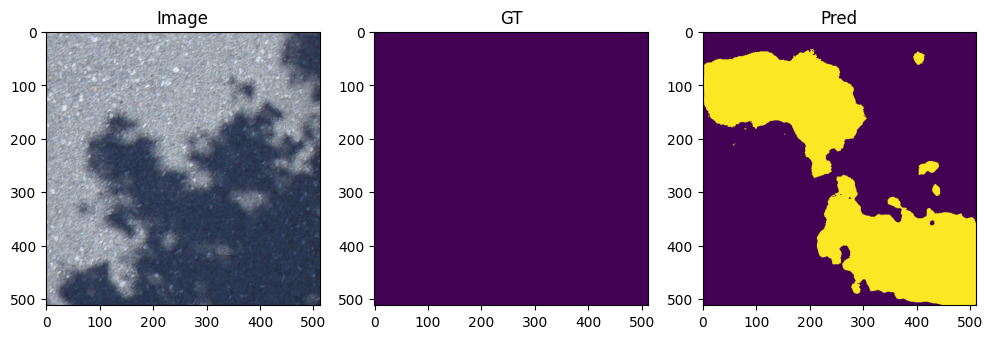

: 

In [ ]:
def visualize():
    model.eval()
    img, msk = dataset[0]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(pred, 1).squeeze(0).cpu().numpy()
    
    plt.figure(figsize=(12, 4))
    plt.subplot(131); plt.imshow(img.permute(1,2,0).numpy() * 0.2 + 0.5); plt.title("Image")
    plt.subplot(132); plt.imshow(msk); plt.title("GT")
    plt.subplot(133); plt.imshow(pred); plt.title("Pred")
    plt.show()

visualize()